# Customer Segmentation & Market Basket Analysis - Online Retail
**Dataset:** Online Retail II (UCI Machine Learning Repository)  
**Methods:** FP-Growth, Apriori, K-Means, Clustering, RFM Segmentation  
**Goal:** Identify customer Groups and cross-sell opportunities across top countries  

---
### Key Findings
- **805,549** valid transactions across 5 countries after cleaning
- Netherlands yields the highest association rule lift (avg 29.3) indicating tight product affinities
- FP-Growth and Apriori produce identical rule sets — FP-Growth is preferred for runtime efficiency
- UK customers split cleanly into 2 segments (silhouette=0.94); Germany/France best at K=3
- Cluster-specific rules reveal distinct product preferences per segment, enabling targeted recommendations

## 1. Setup & Imports

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn mlxtend openpyxl scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 32.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 14.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 48.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 27.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 32.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 48.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [mlxtend]6/17 [mlxtend]ib]n]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Create exports and figures folders
os.makedirs("exports", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load & Clean Data

In [4]:
zip_path = "data/online_retail_II.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:", z.namelist())
    z.extractall(".")

df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1")
print("Original shape:", df.shape)
print(df.head())

Files inside zip: ['online_retail_II.csv']
Original shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity          InvoiceDate  Price  Customer ID         Country
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12  2009-12-01 07:45:00   6.95      13085.0  United Kingdom
1  489434    79323P                   PINK CHERRY LIGHTS        12  2009-12-01 07:45:00   6.75      13085.0  United Kingdom
2  489434    79323W                  WHITE CHERRY LIGHTS        12  2009-12-01 07:45:00   6.75      13085.0  United Kingdom
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48  2009-12-01 07:45:00   2.10      13085.0  United Kingdom
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24  2009-12-01 07:45:00   1.25      13085.0  United Kingdom


In [5]:
data = df.copy()

data = data.rename(columns={
    "Customer ID": "CustomerID",
    "Price": "UnitPrice"
})

# Drop missing values
data = data.dropna(subset=["CustomerID", "Description"])

# Remove cancelled invoices
data = data[~data["Invoice"].astype(str).str.startswith("C")]

# Keep only valid purchases
data = data[data["Quantity"] > 0]
data = data[data["UnitPrice"] > 0]

# Convert types
data["CustomerID"] = data["CustomerID"].astype(int)
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

print("Cleaned shape:", data.shape)
print(data.head())
print(data.isnull().sum())

Cleaned shape: (805549, 9)
  Invoice StockCode                          Description  Quantity         InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12 2009-12-01 07:45:00       6.95       13085  United Kingdom        83.4
1  489434    79323P                   PINK CHERRY LIGHTS        12 2009-12-01 07:45:00       6.75       13085  United Kingdom        81.0
2  489434    79323W                  WHITE CHERRY LIGHTS        12 2009-12-01 07:45:00       6.75       13085  United Kingdom        81.0
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48 2009-12-01 07:45:00       2.10       13085  United Kingdom       100.8
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24 2009-12-01 07:45:00       1.25       13085  United Kingdom        30.0
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPric

## 3. Exploratory Data Analysis

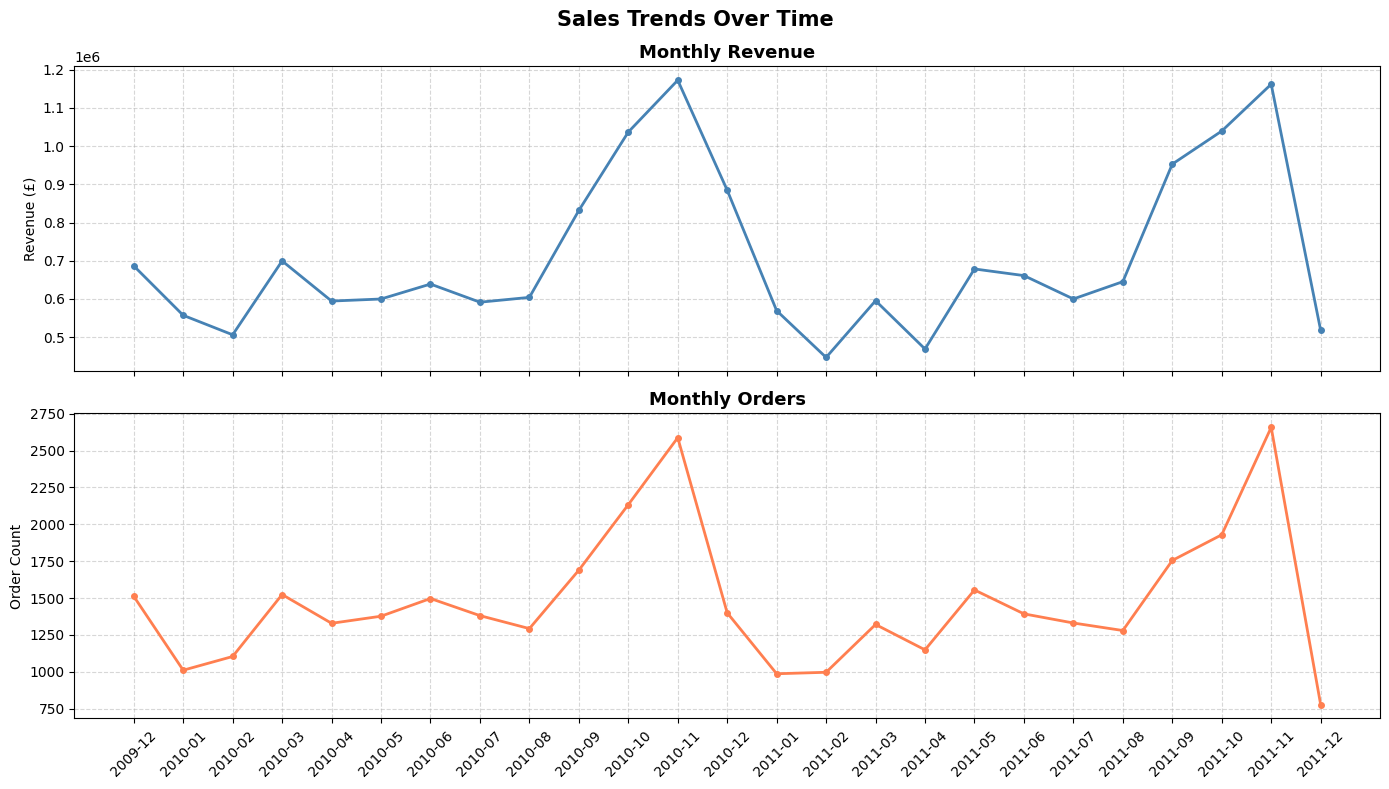

In [6]:
# Revenue over time
data["YearMonth"] = data["InvoiceDate"].dt.to_period("M").astype(str)
monthly = data.groupby("YearMonth").agg(
    Revenue=("TotalPrice", "sum"),
    Orders=("Invoice", "nunique"),
    Customers=("CustomerID", "nunique")
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly["YearMonth"], monthly["Revenue"], color="steelblue", linewidth=2, marker="o", markersize=4)
axes[0].set_title("Monthly Revenue", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Revenue (£)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly["YearMonth"], monthly["Orders"], color="coral", linewidth=2, marker="o", markersize=4)
axes[1].set_title("Monthly Orders", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Order Count")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Sales Trends Over Time", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/monthly_trends.png", dpi=300, bbox_inches="tight")
plt.show()

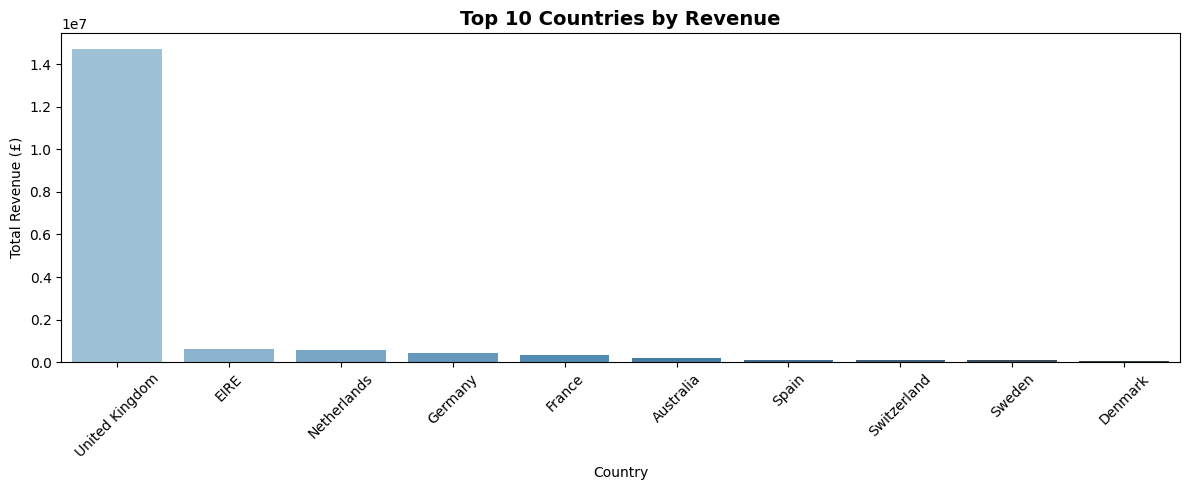

In [7]:
# Revenue by country
country_revenue = data.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=country_revenue.index, y=country_revenue.values, palette="Blues_d")
plt.title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
plt.ylabel("Total Revenue (£)")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/revenue_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

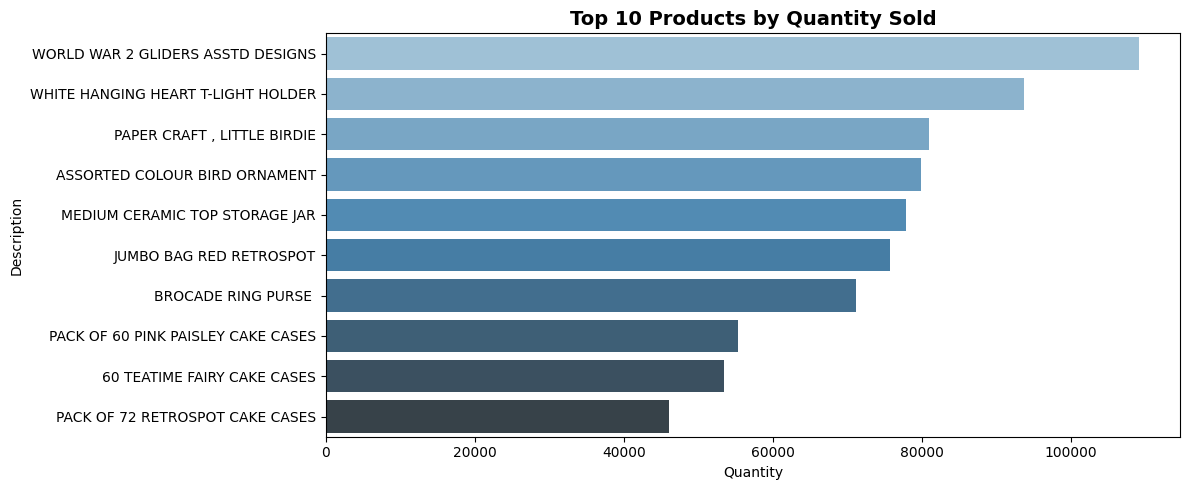

In [8]:
# Top 10 products overall
top_products_overall = (
    data.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_products_overall, x="Quantity", y="Description", palette="Blues_d")
plt.title("Top 10 Products by Quantity Sold", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/top_products_overall.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Country Selection & Main Analysis Loop
Run FP-Growth, Apriori, K-Means, and Agglomerative Clustering per country.

In [9]:
top_countries = data["Country"].value_counts().head(5).index.tolist()
print("Top 5 countries:", top_countries)

Top 5 countries: ['United Kingdom', 'Germany', 'EIRE', 'France', 'Netherlands']


In [10]:
country_results = []
country_top_rules = {}
country_top_rules_ap = {}
country_cluster_profiles = {}
country_top_products = {}
country_cluster_rules = {}
all_customers_list = []   # NEW: for customers_clustered export

for country in top_countries:
    print(f"\n====================")
    print(f"Processing: {country}")
    print("====================")

    country_data = data[data["Country"] == country].copy()
    print("Transactions:", len(country_data))

    # ── Basket creation ──
    basket = (
        country_data.groupby(["Invoice", "Description"])["Quantity"]
        .sum()
        .unstack()
        .fillna(0)
    )
    basket = (basket > 0).astype(int)
    print("Basket shape:", basket.shape)

    if basket.shape[0] < 50:
        print("Skipped association rules (too small)")
        continue

    # ── FP-Growth ──
    freq_items_fp = fpgrowth(basket, min_support=0.03, use_colnames=True)
    rules_fp = association_rules(freq_items_fp, metric="lift", min_threshold=1.0)
    if not rules_fp.empty:
        rules_fp = rules_fp.sort_values(by=["lift", "confidence"], ascending=False)
        country_top_rules[country] = rules_fp[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)
    print("FP-Growth rules:", len(rules_fp))

    # ── Apriori ──
    freq_items_ap = apriori(basket, min_support=0.03, use_colnames=True)
    rules_ap = association_rules(freq_items_ap, metric="lift", min_threshold=1.0)
    if not rules_ap.empty:
        rules_ap = rules_ap.sort_values(by=["lift", "confidence"], ascending=False)
        country_top_rules_ap[country] = rules_ap[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)
    print("Apriori rules:", len(rules_ap))

    # ── Customer features ──
    snapshot = country_data["InvoiceDate"].max()
    customer = country_data.groupby("CustomerID").agg(
        TotalSpending=("TotalPrice", "sum"),
        NumTransactions=("Invoice", "nunique"),
        NumProducts=("StockCode", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        AvgOrderValue=("TotalPrice", "mean"),
        LastPurchase=("InvoiceDate", "max")
    ).reset_index()
    customer["Recency"] = (snapshot - customer["LastPurchase"]).dt.days
    print("Customers:", len(customer))

    if len(customer) < 20:
        print("Skipped clustering (too small)")
        continue

    X = customer[["TotalSpending", "NumTransactions", "NumProducts", "TotalQuantity", "AvgOrderValue"]]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── K-Means selection ──
    k_sil_scores = {}
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        k_sil_scores[k] = score
    best_k = max(k_sil_scores, key=k_sil_scores.get)

    # Final K-Means
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    customer["KMeansCluster"] = kmeans.fit_predict(X_scaled)
    kmeans_score = silhouette_score(X_scaled, customer["KMeansCluster"])

    # Hierarchical
    hier = AgglomerativeClustering(n_clusters=best_k)
    customer["HierCluster"] = hier.fit_predict(X_scaled)
    hier_score = silhouette_score(X_scaled, customer["HierCluster"])

    # Cluster profiles
    profile = customer.groupby("KMeansCluster").mean(numeric_only=True)
    country_cluster_profiles[country] = profile

    # Top products per cluster
    country_data_cluster = country_data.merge(
        customer[["CustomerID", "KMeansCluster"]], on="CustomerID", how="left"
    )
    top_products = (
        country_data_cluster.groupby(["KMeansCluster", "Description"])["Quantity"]
        .sum().reset_index()
        .sort_values(["KMeansCluster", "Quantity"], ascending=[True, False])
    )
    country_top_products[country] = top_products

    # Cluster-specific FP-Growth rules
    country_cluster_rules[country] = {}
    for cluster_id in sorted(customer["KMeansCluster"].unique()):
        cluster_customers = customer[customer["KMeansCluster"] == cluster_id]["CustomerID"]
        cluster_data = country_data[country_data["CustomerID"].isin(cluster_customers)]
        if len(cluster_data["Invoice"].unique()) < 30:
            print(f"  Cluster {cluster_id}: too few invoices, skipping")
            continue
        cluster_basket = (
            cluster_data.groupby(["Invoice", "Description"])["Quantity"]
            .sum().unstack().fillna(0)
        )
        cluster_basket = (cluster_basket > 0).astype(int)
        try:
            freq_cluster = fpgrowth(cluster_basket, min_support=0.05, use_colnames=True)
            if freq_cluster.empty:
                continue
            rules_cluster = association_rules(freq_cluster, metric="lift", min_threshold=1.0)
            if not rules_cluster.empty:
                rules_cluster = rules_cluster.sort_values(["lift", "confidence"], ascending=False)
                country_cluster_rules[country][cluster_id] = rules_cluster[
                    ["antecedents", "consequents", "support", "confidence", "lift"]
                ].head(5)
                print(f"  Cluster {cluster_id}: {len(rules_cluster)} rules found")
        except Exception as e:
            print(f"  Cluster {cluster_id}: rule mining failed ({e})")

    # Collect customer data for export
    customer["Country"] = country
    all_customers_list.append(customer)

    # Summary
    country_results.append({
        "Country": country,
        "Transactions": len(country_data),
        "Invoices": basket.shape[0],
        "Products": basket.shape[1],
        "Customers": len(customer),
        "FP_Rules": len(rules_fp),
        "Apriori_Rules": len(rules_ap),
        "Best_K": best_k,
        "KMeans_Silhouette": round(kmeans_score, 4),
        "Hierarchical_Silhouette": round(hier_score, 4)
    })

results_df = pd.DataFrame(country_results)
print("\n", results_df)


Processing: United Kingdom
Transactions: 725250
Basket shape: (33541, 5249)


/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


FP-Growth rules: 2


/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Apriori rules: 2
Customers: 5350


...

/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


  Cluster 1: 724 rules found
  Cluster 2: too few invoices, skipping

Processing: Netherlands
Transactions: 5088
Basket shape: (228, 1354)
FP-Growth rules: 9368


/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Apriori rules: 9368
Customers: 22
  Cluster 0: 602 rules found
  Cluster 1: 2800 rules found

           Country  Transactions  Invoices  Products  Customers  FP_Rules  Apriori_Rules  Best_K  KMeans_Silhouette  Hierarchical_Silhouette
0  United Kingdom        725250     33541      5249       5350         2              2       2             0.9417                   0.9429
1         Germany         16694       789      2410        107       584            584       3             0.6876                   0.6876
2          France         13812       614      2180         95      1180           1180       3             0.7266                   0.7227
3     Netherlands          5088       228      1354         22      9368           9368       2             0.8976                   0.8976


/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/om/Desktop/DATA_MINING_PROJECT/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


## 5. RFM Segmentation

In [11]:
def rfm_label(row):
    if row["Recency"] < 60 and row["NumTransactions"] >= 5 and row["TotalSpending"] > 500:
        return "Champion"
    elif row["Recency"] < 90 and row["NumTransactions"] >= 3:
        return "Loyal"
    elif row["Recency"] < 180:
        return "At Risk"
    else:
        return "Lost"

all_customers_df = pd.concat(all_customers_list, ignore_index=True)
all_customers_df["RFM_Segment"] = all_customers_df.apply(rfm_label, axis=1)

print(all_customers_df[["CustomerID", "Country", "KMeansCluster", "RFM_Segment",
                         "TotalSpending", "NumTransactions", "Recency"]].head(10))
print("\nRFM Segment distribution:")
print(all_customers_df["RFM_Segment"].value_counts())

   CustomerID         Country  KMeansCluster RFM_Segment  TotalSpending  NumTransactions  Recency
0       12346  United Kingdom              1        Lost       77556.46               12      325
1       12608  United Kingdom              0        Lost         415.79                1      404
2       12745  United Kingdom              0        Lost         723.85                2      486
3       12746  United Kingdom              0        Lost         254.55                1      540
4       12747  United Kingdom              0    Champion        9276.54               26        1
5       12748  United Kingdom              1    Champion       56599.39              336        0
6       12749  United Kingdom              0    Champion        6897.36                9        3
7       12777  United Kingdom              0        Lost         519.45                1      457
8       12819  United Kingdom              0        Lost         540.52                1      457
9       12820  Unite

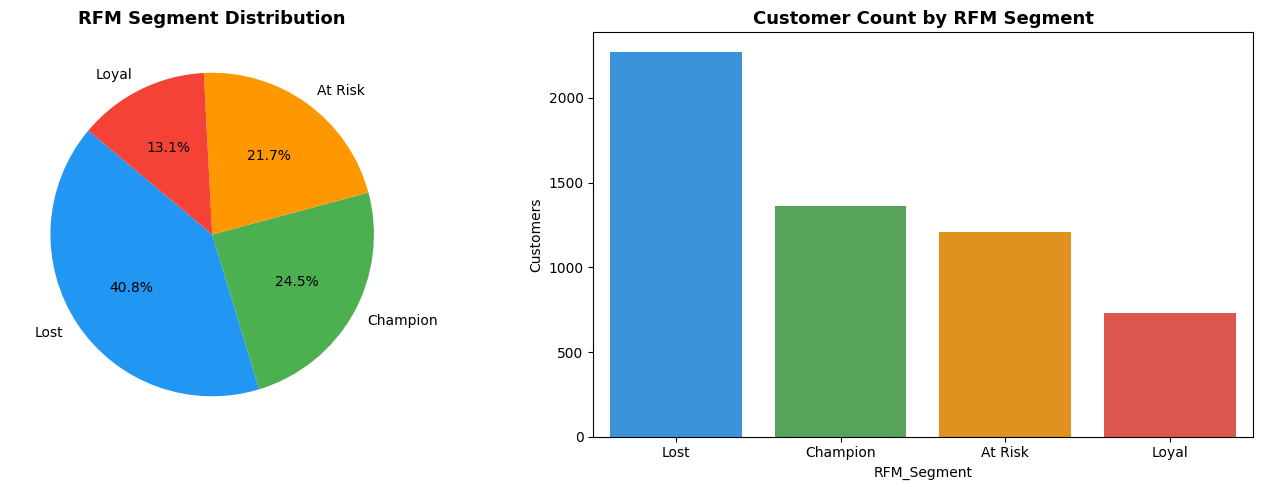

In [12]:
# RFM segment distribution chart
seg_counts = all_customers_df["RFM_Segment"].value_counts()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[0].set_title("RFM Segment Distribution", fontsize=13, fontweight="bold")

sns.barplot(x=seg_counts.index, y=seg_counts.values, palette=colors, ax=axes[1])
axes[1].set_title("Customer Count by RFM Segment", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Customers")

plt.tight_layout()
plt.savefig("figures/rfm_segments.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# RFM segment avg spend & recency
rfm_profile = all_customers_df.groupby("RFM_Segment").agg(
    AvgSpend=("TotalSpending", "mean"),
    AvgRecency=("Recency", "mean"),
    AvgTransactions=("NumTransactions", "mean"),
    Count=("CustomerID", "count")
).round(2).reset_index()

print(rfm_profile.to_string(index=False))

RFM_Segment  AvgSpend  AvgRecency  AvgTransactions  Count
    At Risk   1221.01       81.51             3.11   1207
   Champion   8135.59       19.38            16.06   1365
       Lost    955.94      420.99             2.60   2274
      Loyal   1801.19       43.98             4.92    728


## 6. FP-Growth vs Apriori Comparison

In [14]:
comparison_rows = []
for country in country_top_rules:
    fp = country_top_rules[country]
    row = {
        "Country": country,
        "FP_RuleCount": len(fp),
        "FP_AvgLift": round(fp["lift"].mean(), 3),
        "FP_AvgConfidence": round(fp["confidence"].mean(), 3),
        "FP_AvgSupport": round(fp["support"].mean(), 4),
    }
    if country in country_top_rules_ap:
        ap = country_top_rules_ap[country]
        row.update({
            "AP_RuleCount": len(ap),
            "AP_AvgLift": round(ap["lift"].mean(), 3),
            "AP_AvgConfidence": round(ap["confidence"].mean(), 3),
            "AP_AvgSupport": round(ap["support"].mean(), 4),
        })
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
print("FP-Growth vs Apriori – Rule Quality Comparison")
print(comparison_df.to_string(index=False))

FP-Growth vs Apriori – Rule Quality Comparison
       Country  FP_RuleCount  FP_AvgLift  FP_AvgConfidence  FP_AvgSupport  AP_RuleCount  AP_AvgLift  AP_AvgConfidence  AP_AvgSupport
United Kingdom             2       5.036             0.469         0.0326             2       5.036             0.469         0.0326
       Germany            10      15.223             0.729         0.0342            10      15.223             0.729         0.0342
          EIRE            10      18.270             0.791         0.0349            10      18.270             0.791         0.0349
        France            10      18.798             0.806         0.0342            10      18.798             0.806         0.0342
   Netherlands            10      29.314             0.975         0.0316            10      29.314             0.975         0.0316


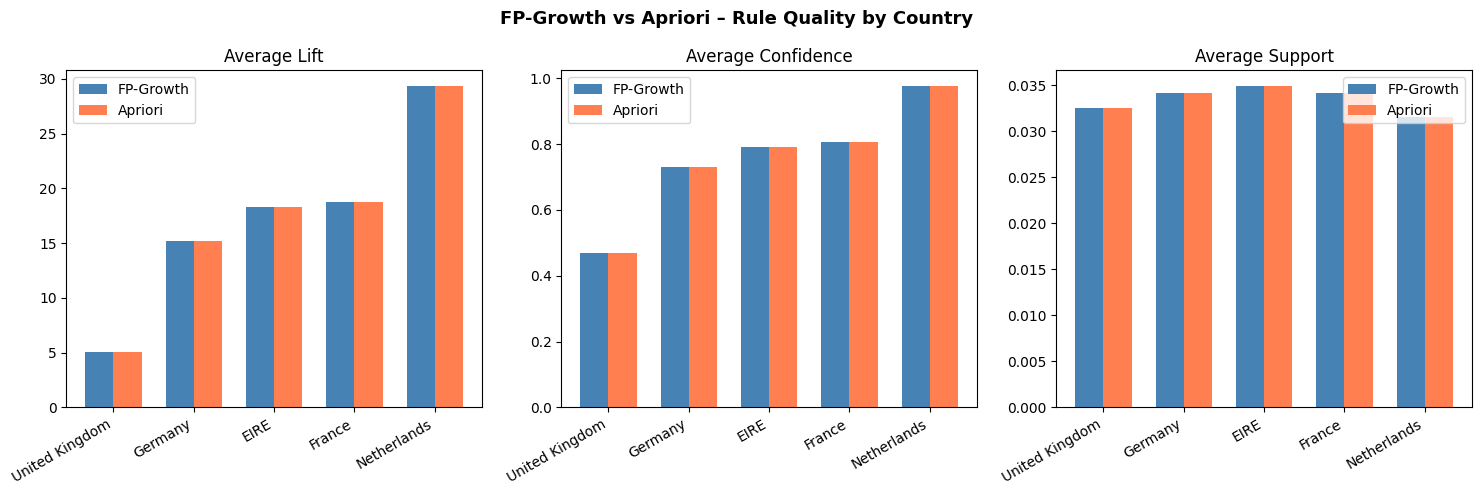

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [("AvgLift", "Average Lift"), ("AvgConfidence", "Average Confidence"), ("AvgSupport", "Average Support")]
for ax, (metric, label) in zip(axes, metrics):
    x = comparison_df["Country"]
    fp_vals = comparison_df[f"FP_{metric}"]
    ap_vals = comparison_df.get(f"AP_{metric}", fp_vals)
    width = 0.35
    x_pos = range(len(x))
    ax.bar([p - width/2 for p in x_pos], fp_vals, width, label="FP-Growth", color="steelblue")
    ax.bar([p + width/2 for p in x_pos], ap_vals, width, label="Apriori", color="coral")
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(x, rotation=30, ha="right")
    ax.set_title(label)
    ax.legend()
plt.suptitle("FP-Growth vs Apriori – Rule Quality by Country", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fp_vs_apriori_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Clustering Analysis

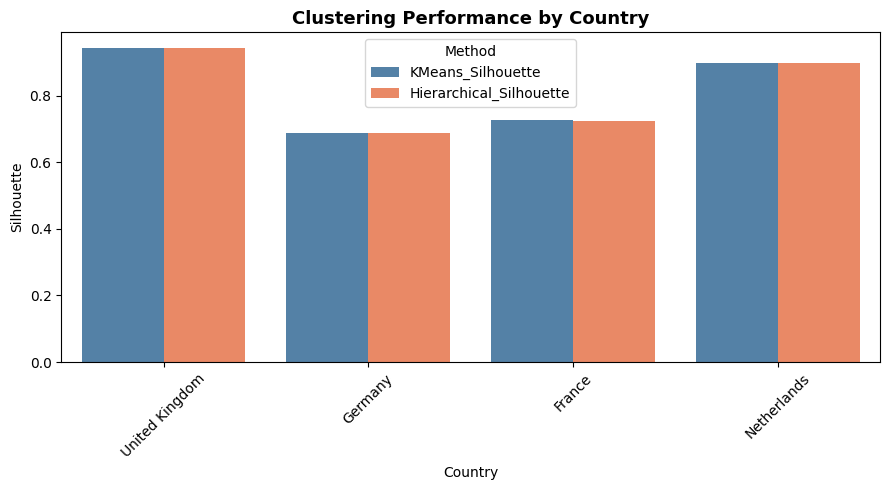

In [16]:
# Silhouette scores by country
sil_plot = results_df.melt(
    id_vars="Country",
    value_vars=["KMeans_Silhouette", "Hierarchical_Silhouette"],
    var_name="Method",
    value_name="Silhouette"
)
plt.figure(figsize=(9, 5))
sns.barplot(data=sil_plot, x="Country", y="Silhouette", hue="Method", palette=["steelblue", "coral"])
plt.title("Clustering Performance by Country", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()

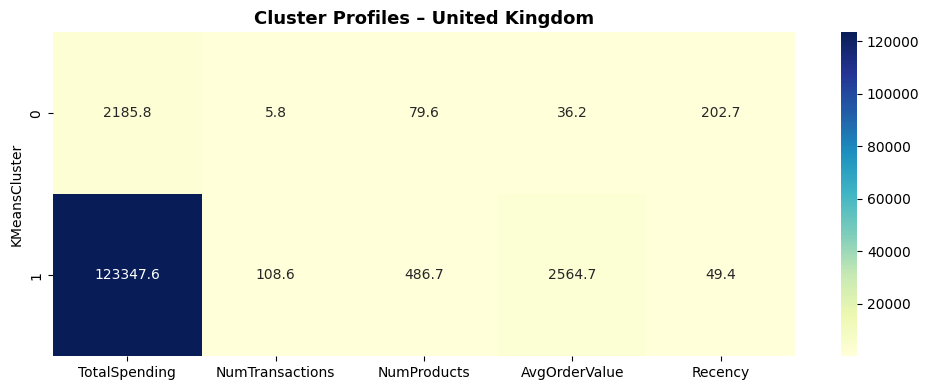

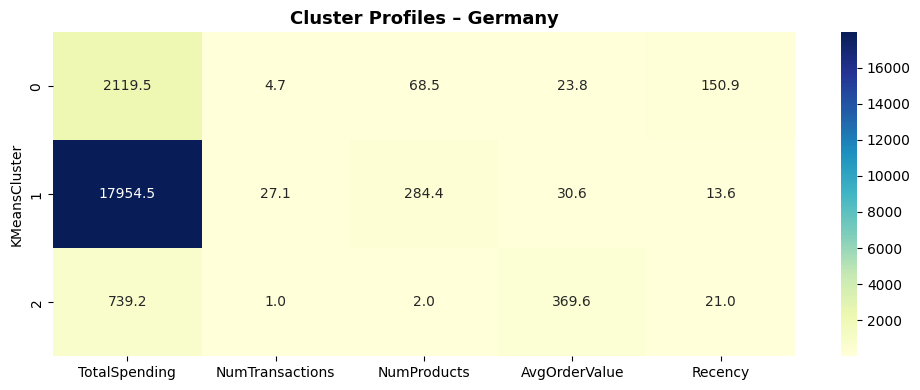

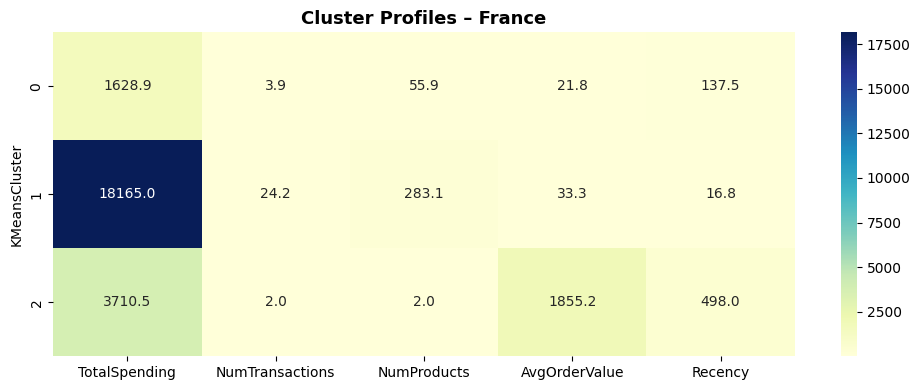

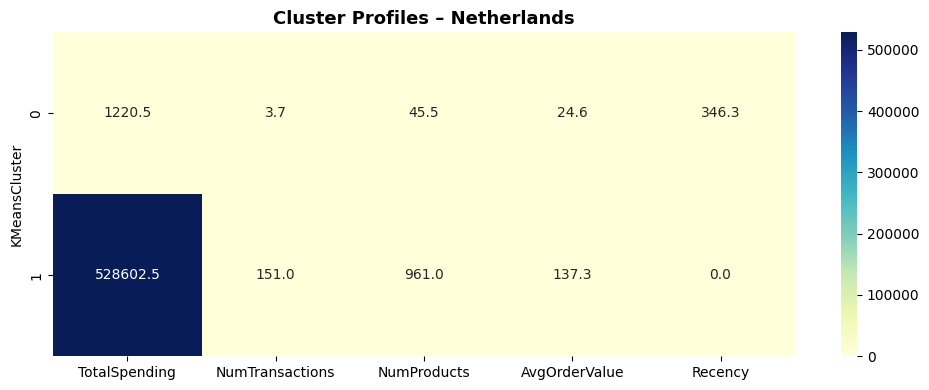

In [17]:
# Cluster profile heatmaps for each country
for country_name, profile in country_cluster_profiles.items():
    plt.figure(figsize=(10, 4))
    sns.heatmap(profile[["TotalSpending", "NumTransactions", "NumProducts", "AvgOrderValue", "Recency"]],
                annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title(f"Cluster Profiles – {country_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    safe = country_name.replace(" ", "_")
    plt.savefig(f"figures/cluster_profile_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()

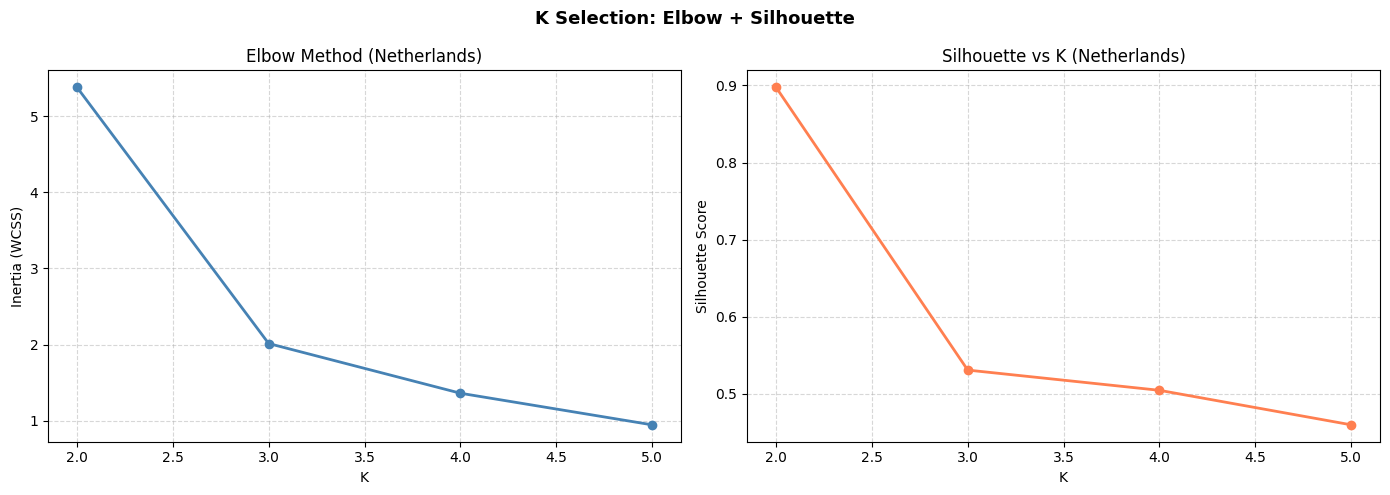

In [18]:
# Elbow + Silhouette (Netherlands — last country)
last_country = results_df.iloc[-1]["Country"]
last_customer = all_customers_df[all_customers_df["Country"] == last_country].copy()
X_last = last_customer[["TotalSpending", "NumTransactions", "NumProducts", "TotalQuantity", "AvgOrderValue"]]
X_last_scaled = StandardScaler().fit_transform(X_last)

inertias, sil_scores = [], []
k_range = range(2, 6)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_last_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_last_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title(f"Elbow Method ({last_country})")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(list(k_range), sil_scores, marker="o", color="coral", linewidth=2)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title(f"Silhouette vs K ({last_country})")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("K Selection: Elbow + Silhouette", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/elbow_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

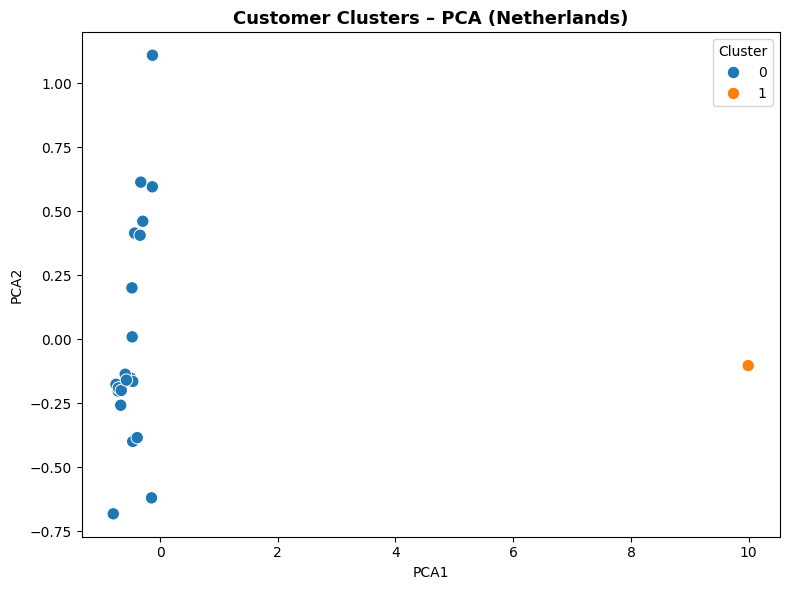

In [19]:
# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_last_scaled)
last_customer = last_customer.copy()
last_customer["PCA1"] = X_pca[:, 0]
last_customer["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=last_customer, x="PCA1", y="PCA2", hue="KMeansCluster", palette="tab10", s=80)
plt.title(f"Customer Clusters – PCA ({last_country})", fontsize=13, fontweight="bold")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("figures/pca_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

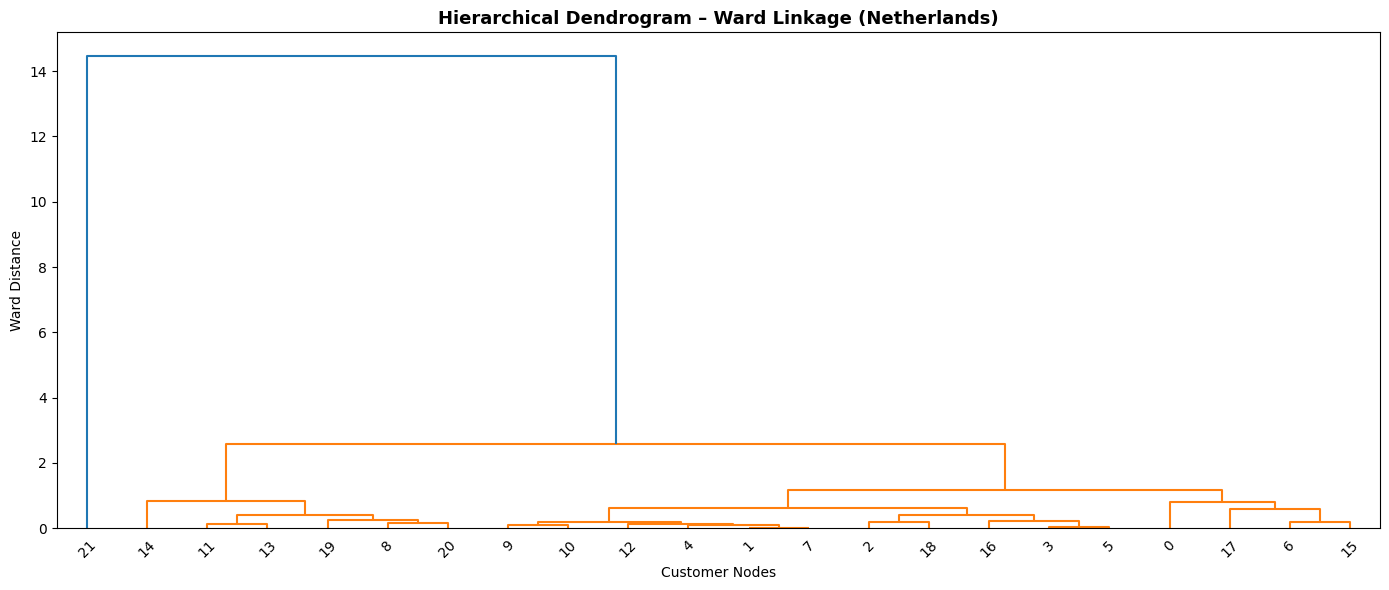

In [20]:
# Dendrogram
linked = linkage(X_last_scaled, method="ward")
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title(f"Hierarchical Dendrogram – Ward Linkage ({last_country})", fontsize=13, fontweight="bold")
plt.xlabel("Customer Nodes")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.savefig("figures/dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Cluster-Specific Association Rules

In [21]:
for country, cluster_rules_dict in country_cluster_rules.items():
    print(f"\n{'='*55}")
    print(f"  {country} – Cluster-Specific Association Rules")
    print(f"{'='*55}")
    if not cluster_rules_dict:
        print("  No rules generated (insufficient data).")
        continue
    for cluster_id, rules in cluster_rules_dict.items():
        print(f"\n  Cluster {cluster_id} (top rules by lift):")
        for _, row in rules.iterrows():
            ant = ", ".join(list(row["antecedents"]))
            con = ", ".join(list(row["consequents"]))
            print(f"    [{ant}] → [{con}]  "
                  f"lift={row['lift']:.2f}  conf={row['confidence']:.2f}  sup={row['support']:.4f}")


  United Kingdom – Cluster-Specific Association Rules

  Cluster 1 (top rules by lift):
    [WOODEN FRAME ANTIQUE WHITE ] → [WOODEN PICTURE FRAME WHITE FINISH]  lift=10.21  conf=0.76  sup=0.0501
    [WOODEN PICTURE FRAME WHITE FINISH] → [WOODEN FRAME ANTIQUE WHITE ]  lift=10.21  conf=0.67  sup=0.0501

  Germany – Cluster-Specific Association Rules

  Cluster 0 (top rules by lift):
    [PLASTERS IN TIN SPACEBOY] → [PLASTERS IN TIN WOODLAND ANIMALS]  lift=4.21  conf=0.61  sup=0.0642
    [PLASTERS IN TIN WOODLAND ANIMALS] → [PLASTERS IN TIN SPACEBOY]  lift=4.21  conf=0.44  sup=0.0642
    [PLASTERS IN TIN SPACEBOY] → [POSTAGE, PLASTERS IN TIN WOODLAND ANIMALS]  lift=4.16  conf=0.54  sup=0.0573
    [POSTAGE, PLASTERS IN TIN WOODLAND ANIMALS] → [PLASTERS IN TIN SPACEBOY]  lift=4.16  conf=0.44  sup=0.0573
    [PLASTERS IN TIN SPACEBOY, POSTAGE] → [PLASTERS IN TIN WOODLAND ANIMALS]  lift=4.02  conf=0.58  sup=0.0573

  Cluster 1 (top rules by lift):
    [SAVE THE PLANET COTTON TOTE BAG] → [WOO

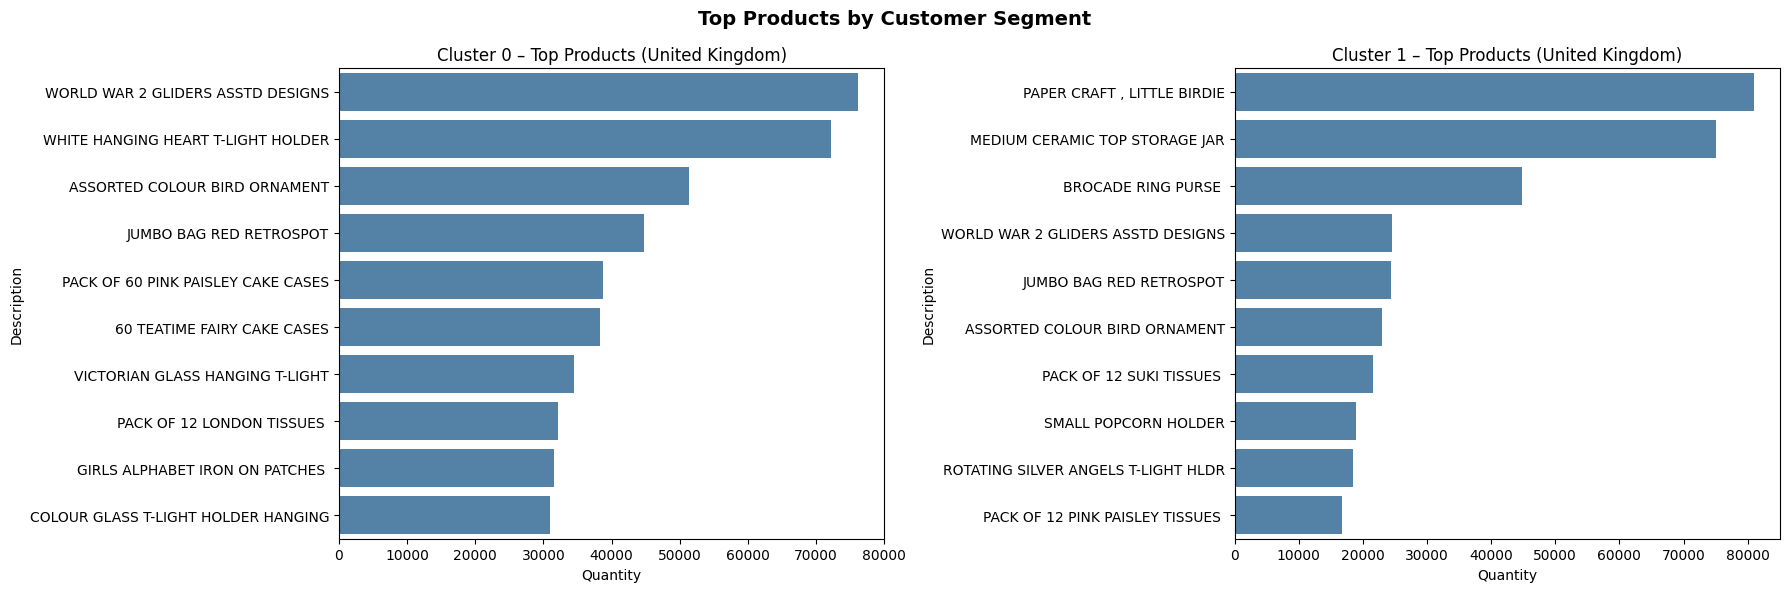

In [22]:
# Top products per cluster – UK
country_name = "United Kingdom"
if country_name in country_top_products:
    top_p = country_top_products[country_name]
    clusters = sorted(top_p["KMeansCluster"].dropna().unique())[:2]
    fig, axes = plt.subplots(1, len(clusters), figsize=(18, 6))
    if len(clusters) == 1:
        axes = [axes]
    for cluster_id, ax in zip(clusters, axes):
        cp = top_p[top_p["KMeansCluster"] == cluster_id].head(10)
        sns.barplot(data=cp, x="Quantity", y="Description", color="steelblue", ax=ax)
        ax.set_title(f"Cluster {int(cluster_id)} – Top Products ({country_name})", fontsize=12)
    plt.suptitle("Top Products by Customer Segment", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/top_products_by_cluster.png", dpi=300, bbox_inches="tight")
    plt.show()

## 9. Export CSVs for Power BI

In [23]:
# 1. customers_clustered.csv
all_customers_df.drop(columns=["LastPurchase"], errors="ignore").to_csv(
    "exports/customers_clustered.csv", index=False
)
print("✓ customers_clustered.csv:", all_customers_df.shape)

# 2. monthly_revenue.csv
monthly.to_csv("exports/monthly_revenue.csv", index=False)
print("✓ monthly_revenue.csv:", monthly.shape)

# 3. association_rules_export.csv
rules_rows = []
for country, rules in country_top_rules.items():
    for _, row in rules.iterrows():
        rules_rows.append({
            "Country": country,
            "Antecedent": ", ".join(list(row["antecedents"])),
            "Consequent": ", ".join(list(row["consequents"])),
            "Support": round(row["support"], 4),
            "Confidence": round(row["confidence"], 4),
            "Lift": round(row["lift"], 4),
            "Method": "FP-Growth"
        })
rules_export = pd.DataFrame(rules_rows)
rules_export.to_csv("exports/association_rules_export.csv", index=False)
print("✓ association_rules_export.csv:", rules_export.shape)

# 4. top_products.csv
all_top_products = []
for country, df_p in country_top_products.items():
    df_p = df_p.copy()
    df_p["Country"] = country
    all_top_products.append(df_p.head(20))
pd.concat(all_top_products).to_csv("exports/top_products.csv", index=False)
print("✓ top_products.csv")

# 5. method_comparison.csv
comparison_df.to_csv("exports/method_comparison.csv", index=False)
print("✓ method_comparison.csv")

# 6. country_summary.csv
results_df.to_csv("exports/country_summary.csv", index=False)
print("✓ country_summary.csv")

# 7. rfm_profile.csv
rfm_profile.to_csv("exports/rfm_profile.csv", index=False)
print("✓ rfm_profile.csv")

print("\nAll exports saved to /exports/")

✓ customers_clustered.csv: (5574, 12)
✓ monthly_revenue.csv: (25, 4)
✓ association_rules_export.csv: (42, 7)
✓ top_products.csv
✓ method_comparison.csv
✓ country_summary.csv
✓ rfm_profile.csv

All exports saved to /exports/


## 10. Summary Tables

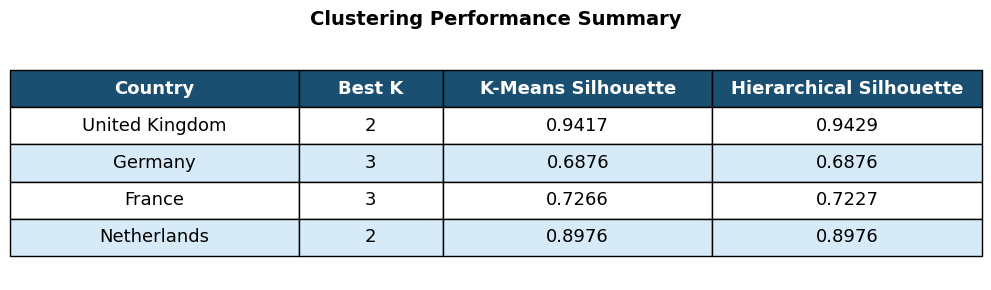

In [24]:
# Clustering results summary table
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

table_data = [
    ["United Kingdom", "2", "0.9417", "0.9429"],
    ["Germany",        "3", "0.6876", "0.6876"],
    ["France",         "3", "0.7266", "0.7227"],
    ["Netherlands",    "2", "0.8976", "0.8976"],
]
columns = ["Country", "Best K", "K-Means Silhouette", "Hierarchical Silhouette"]

table = ax.table(cellText=table_data, colLabels=columns,
                 cellLoc="center", loc="center",
                 colWidths=[0.3, 0.15, 0.28, 0.28])
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2.2)

for j in range(4):
    table[0, j].set_facecolor("#1B4F72")
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(table_data) + 1):
    for j in range(4):
        table[i, j].set_facecolor("#D6EAF8" if i % 2 == 0 else "white")

plt.title("Clustering Performance Summary", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("figures/clustering_results_table.png", dpi=300, bbox_inches="tight")
plt.show()

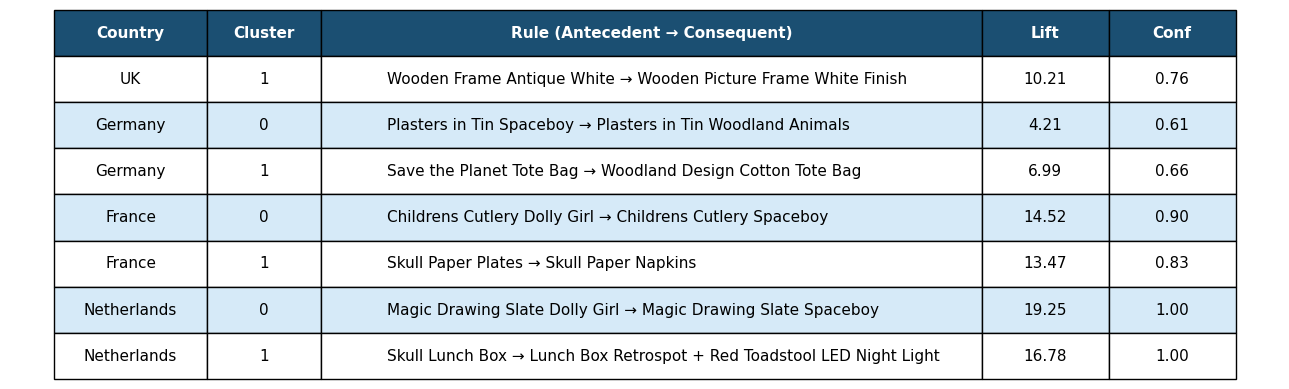

In [25]:
# Cluster rules summary table
fig, ax = plt.subplots(figsize=(13, 4), facecolor="white")
ax.axis("off")

table_data = [
    ["UK",          "1", "Wooden Frame Antique White → Wooden Picture Frame White Finish",         "10.21", "0.76"],
    ["Germany",     "0", "Plasters in Tin Spaceboy → Plasters in Tin Woodland Animals",            "4.21",  "0.61"],
    ["Germany",     "1", "Save the Planet Tote Bag → Woodland Design Cotton Tote Bag",             "6.99",  "0.66"],
    ["France",      "0", "Childrens Cutlery Dolly Girl → Childrens Cutlery Spaceboy",              "14.52", "0.90"],
    ["France",      "1", "Skull Paper Plates → Skull Paper Napkins",                               "13.47", "0.83"],
    ["Netherlands", "0", "Magic Drawing Slate Dolly Girl → Magic Drawing Slate Spaceboy",          "19.25", "1.00"],
    ["Netherlands", "1", "Skull Lunch Box → Lunch Box Retrospot + Red Toadstool LED Night Light",  "16.78", "1.00"],
]
columns = ["Country", "Cluster", "Rule (Antecedent → Consequent)", "Lift", "Conf"]

table = ax.table(cellText=table_data, colLabels=columns,
                 cellLoc="center", loc="center",
                 colWidths=[0.12, 0.09, 0.52, 0.1, 0.1])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.8)

for j in range(5):
    table[0, j].set_facecolor("#1B4F72")
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(table_data) + 1):
    for j in range(5):
        table[i, j].set_facecolor("#D6EAF8" if i % 2 == 0 else "white")
for i in range(1, len(table_data) + 1):
    table[i, 2].set_text_props(ha="left")

plt.tight_layout()
plt.savefig("figures/cluster_rules_table.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()